In [1]:
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

In [2]:
%cd ../../

c:\Users\Matth\OneDrive\Documents\UMD\classes\junior year\Summer\research\R determination


In [3]:
import Util
import Spec1D
import Spec2D
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

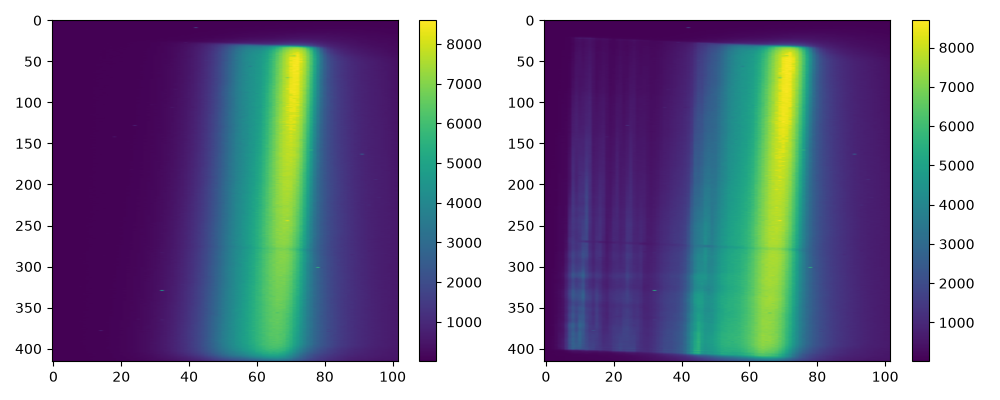

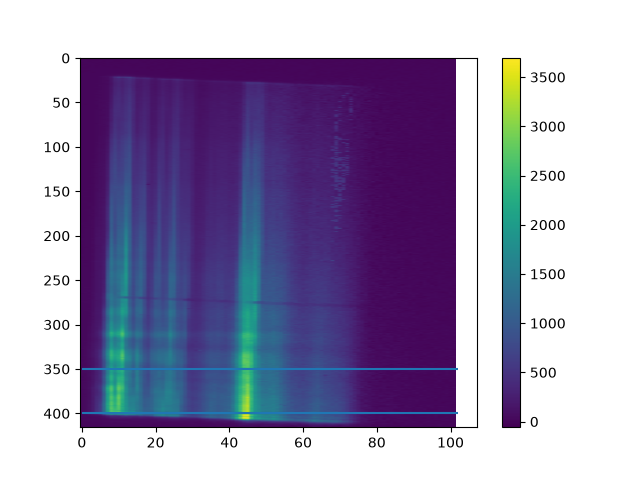

In [4]:
bgPath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\step2\\20250123.rimas.0090.HK.fits"
dirtySpecPath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\step2\\20250123.rimas.0091.HK.fits"
bg = fits.open(bgPath)[0].data
bg[np.isnan(bg)] = -1
dirtySpec = fits.open(dirtySpecPath)[0].data
dirtySpec[np.isnan(dirtySpec)] = -1

Spec2D.flipY(bg)
Spec2D.flipY(dirtySpec)

bg = Spec2D.cropImage(bg, 83, 1098, 416, 102)
dirtySpec = Spec2D.cropImage(dirtySpec, 83, 1098, 416, 102)

fig, ax = plt.subplots(1,2, figsize=(10,4))
img1 = ax[0].imshow(bg, vmin=np.min(bg), vmax=np.max(bg))
fig.colorbar(img1)
ax[0].set_aspect("auto")
img2 = ax[1].imshow(dirtySpec, vmin=np.min(dirtySpec), vmax=np.max(dirtySpec))
fig.colorbar(img2)
ax[1].set_aspect("auto")
fig.tight_layout()

minY = 350
maxY = 400

specImg = dirtySpec-bg
fig2, ax2 = plt.subplots()
img = ax2.imshow(specImg, vmin=np.min(specImg), vmax=np.max(specImg))
ax2.hlines([minY, maxY], 0, 102)
fig2.colorbar(img)
ax2.set_aspect("auto")

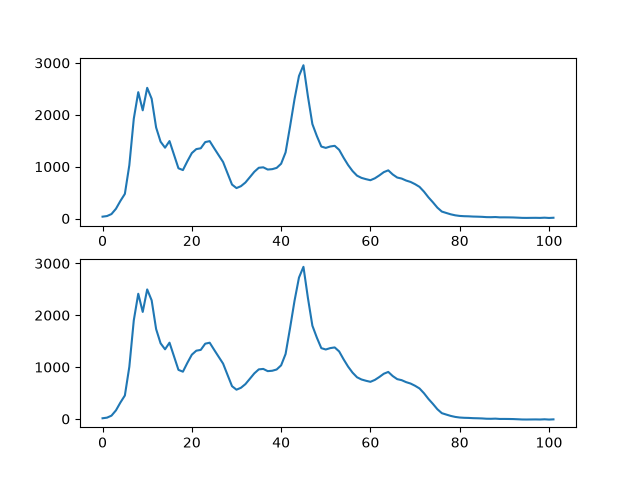

In [5]:
linePath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\XeHgArKr_lines.dat"
lines =  Util.createLineList(linePath, mergedLines=["Xe", "Hg"])

spec = Spec1D.convert2Dto1D(specImg, minY, maxY)
continuum = Spec1D.continuum(spec, thresh=1, debug=False)
contSub = spec - continuum(np.arange(0, len(spec)))

fig, ax = plt.subplots(2,1)
ax[0].plot(spec)
ax[1].plot(contSub)

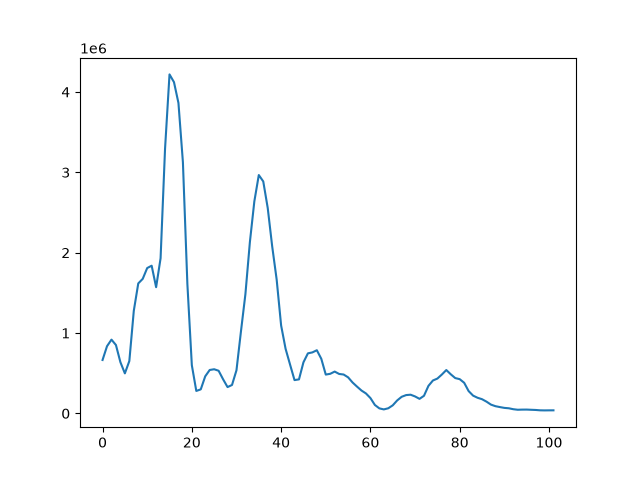

In [6]:
fig, ax = plt.subplots()
ax.plot(Spec1D.calcModel(lines, 102, 14000, 0.012))

14876.254180602007 0.021076923076923076


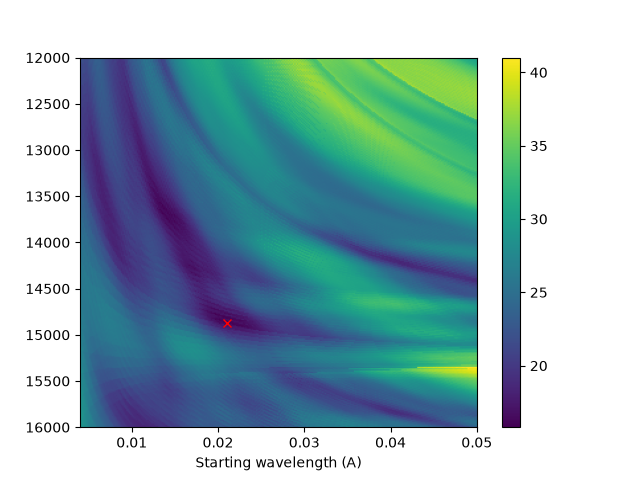

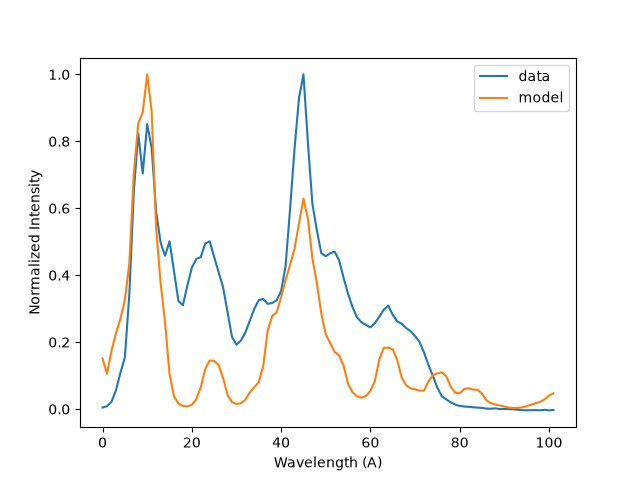

In [7]:
w, a = Spec1D.calcLinearFit(contSub, lines, 12000, 16000, 0.004, 0.05, resW=300, resS=300)
print(w, a)

In [ ]:
w = 14876.254180602007
a = 0.021076923076923076

In [ ]:
wavs = np.linspace(Spec1D.pixelToWav(0, w, a), Spec1D.pixelToWav(len(contSub)-1, w, a), len(contSub))
norm = contSub/np.max(contSub)
params = []
model = np.zeros_like(norm)

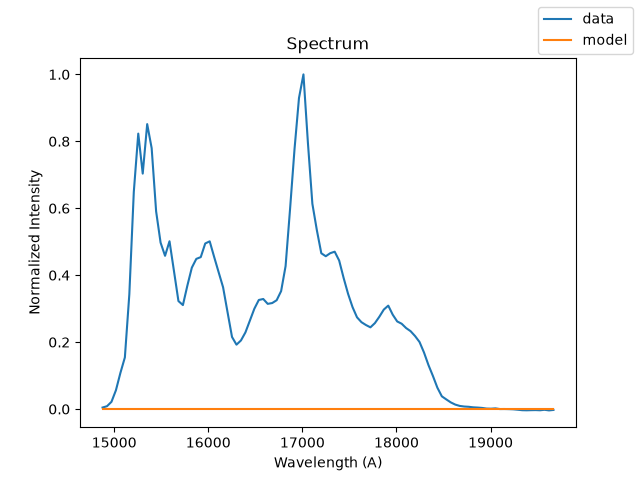

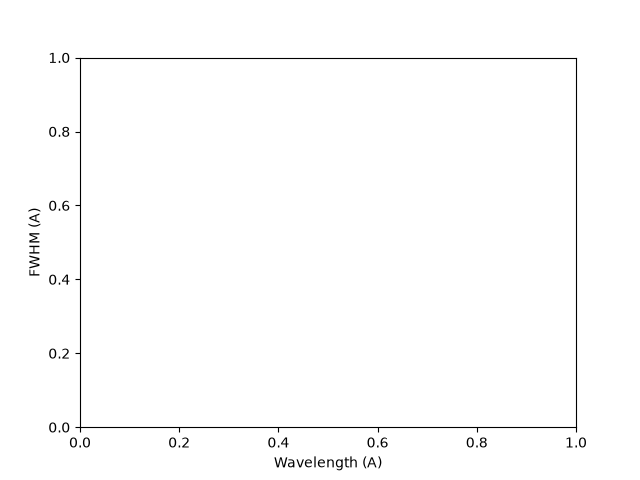

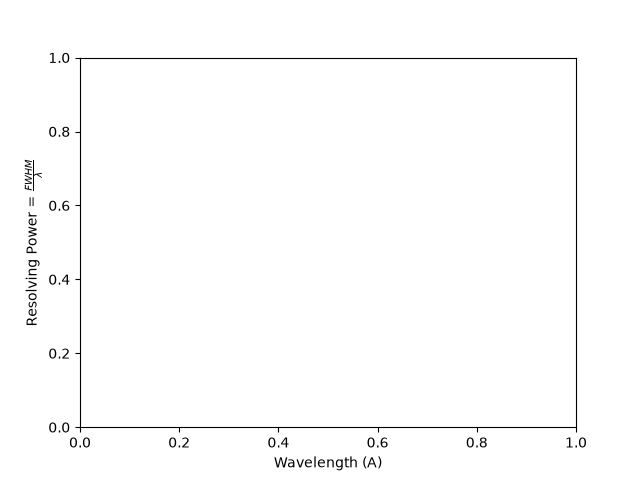

In [9]:
fig, ax = plt.subplots()
ax.set_title("Spectrum")
ax.set_xlabel("Wavelength (A)")
ax.set_ylabel("Normalized Intensity")
ax.plot(wavs,norm, label="data")
line, = ax.plot(wavs, model, label="model")
fig.legend()

FWFig, FWAx = plt.subplots()
FWAx.set_xlabel("Wavelength (A)")
FWAx.set_ylabel("FWHM (A)")
RFig, RAx = plt.subplots()
RAx.set_xlabel("Wavelength (A)")
RAx.set_ylabel("Resolving Power = $\\frac{FWHM}{\\lambda}$")

def updateGraphs():
    line.set_ydata(model)
    fig.canvas.draw()
    fig.canvas.flush_events()

    tmp = np.array(params)
    FWHMs = Spec1D.LorentzWidthToFWHM(tmp[:,2])
    FWAx.clear()
    FWAx.plot(tmp[:,0], FWHMs, "o")
    FWAx.set_xlabel("Wavelength (A)")
    FWAx.set_ylabel("FWHM (A)")
    FWFig.canvas.draw()
    FWFig.canvas.flush_events()

    RAx.clear()
    RAx.plot(tmp[:,0], tmp[:,0]/FWHMs, "o")
    RAx.set_xlabel("Wavelength (A)")
    RAx.set_ylabel("Resolving Power = $\\frac{FWHM}{\\lambda}$")
    RFig.canvas.draw()
    RFig.canvas.flush_events()

if len(params)>0:
    updateGraphs()

def onclick(event):
    global model
    if edit:
        if event.button == 1: #button 1 is left mouse button
            l = event.xdata
            index=Spec1D.wavToPixel(l, w, a)
            intensities=norm[index-3:index+3]
            wavSec = wavs[index-3:index+3]
            var, cov = curve_fit(Spec1D.LorentzLine, wavSec, intensities, (l, event.ydata, 20, 0, 2),bounds=([l-50,0,0,0,0],[l+50, 1,200,1e-5,np.inf]), sigma=np.sqrt(np.abs(intensities)), absolute_sigma=True)
            params.append(var)
            #params is center wavelength, amplitude, width, offset, and power
            model += Spec1D.LorentzLine(wavs, params[-1][0], params[-1][1], params[-1][2], 0, params[-1][4])

            #refresh the canvas
        if event.button == 3: #right mouse button
            model -= Spec1D.LorentzLine(wavs, params[-1][0], params[-1][1], params[-1][2], 0, params[-1][4])
            params.pop()
        
        updateGraphs()

edit = False
def onkey(event):
    global edit
    print(event.key)
    if event.key == "e":
        if edit:
            edit = False
        else:
            edit = True

cid = fig.canvas.mpl_connect('button_press_event', onclick)
cid = fig.canvas.mpl_connect('key_press_event', onkey)

In [10]:
tmp = np.array(params)
FWHMs = Spec1D.LorentzWidthToFWHM(tmp[:,2])
Rs = tmp[:,0]/FWHMs
print(Rs)
print(np.median(Rs))

[55.65562    52.15453668]
53.90507834281773
